# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


python 3.11.16 | torch 2.14.0+cu130 | timm 1.0.30
GPU: NVIDIA GeForce RTX 5060 Ti


c:\Users\manhc\miniconda3\envs\attack\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [ ]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

In [3]:
IMAGES_DIR = "data/images"   # TODO: kiểm tra đúng thư mục chứa các file .jpg sau khi giải nén
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
All 17,509 image files exist.
Số ảnh mỗi tập:
  train: 10,501
    val: 3,501
   test: 3,507

Số ảnh mỗi lớp trong từng tập:


,train,val,test,total
class,,,,
Chinee Apple,675,225,226,1126
Lantana,637,213,213,1063
Parkinsonia,618,206,207,1031
Parthenium,613,204,205,1022
Prickly Acacia,637,212,213,1062
Rubber Vine,605,202,202,1009
Siam Weed,644,215,215,1074
Snake Weed,609,203,204,1016
Negatives,5463,1821,1822,9106


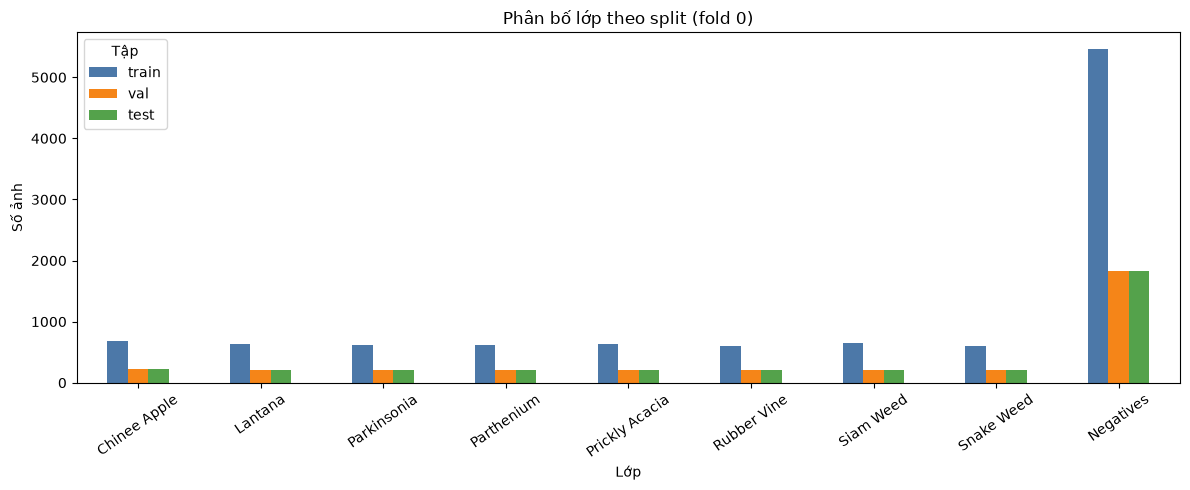

Đối chiếu với Table 1 (tổng kỳ vọng: 17,509 ảnh):


,Đếm từ CSV,Table 1,Chênh lệch
Chinee Apple,1126,1125,1
Lantana,1063,1064,-1
Parkinsonia,1031,1031,0
Parthenium,1022,1022,0
Prickly Acacia,1062,1062,0
Rubber Vine,1009,1009,0
Siam Weed,1074,1074,0
Snake Weed,1016,1016,0
Negatives,9106,9106,0


Các lớp lệch so với Table 1 (CSV vẫn có thể đúng tổng 17,509 ảnh):


,Đếm từ CSV,Table 1,Chênh lệch
Chinee Apple,1126,1125,1
Lantana,1063,1064,-1


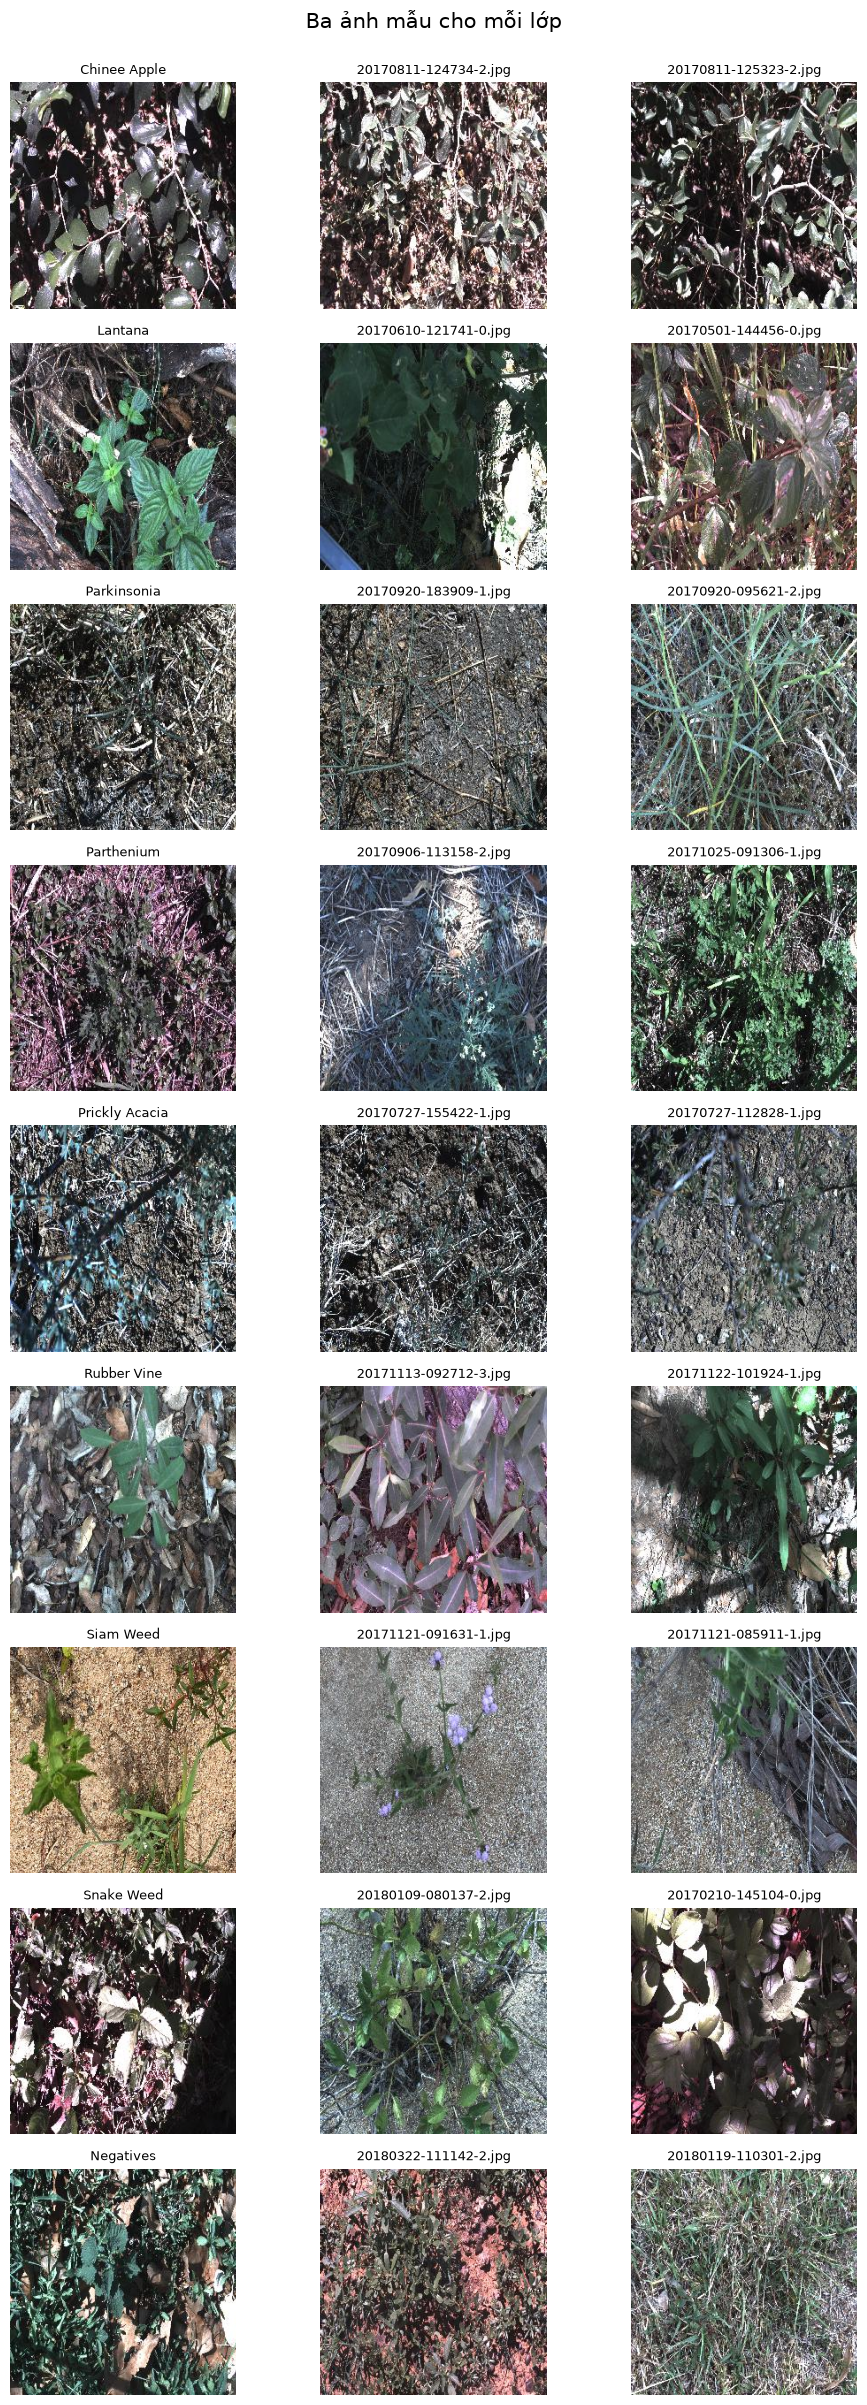

In [6]:
# TODO: đọc split bằng dataset.load_split, chạy dataset.check_split(...), in số ảnh mỗi tập và mỗi lớp.
# TODO: vẽ biểu đồ phân bố lớp; xem >= 3 ảnh mỗi lớp; đối chiếu với Table 1 của bài báo
#       (Negatives 9.106; các loài 1.009-1.125 ảnh).

import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import importlib
import dataset
dataset = importlib.reload(dataset)  # nhận code mới nếu dataset.py vừa được sửa

# Chuẩn hóa đường dẫn khi notebook được mở từ thư mục gốc hoặc từ starter/.
project_root = Path(dataset.__file__).resolve().parent.parent
labels_path = Path(LABELS_DIR)
if not labels_path.is_dir():
    labels_path = project_root / labels_path
LABELS_DIR = str(labels_path)

# Một số bản giải nén tạo thêm thư mục data/images/images.
images_path = Path(IMAGES_DIR)
if not images_path.is_dir():
    images_path = project_root / images_path
if not any(images_path.glob("*.jpg")) and (images_path / "images").is_dir():
    images_path = images_path / "images"
IMAGES_DIR = str(images_path)

# Đọc đúng fold 0 do tác giả cung cấp và chạy toàn bộ kiểm tra split bắt buộc.
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_report = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
splits = {"train": train_df, "val": val_df, "test": test_df}

print("Số ảnh mỗi tập:")
for split_name, split_df in splits.items():
    print(f"  {split_name:>5}: {len(split_df):,}")

# Hàng là lớp, cột là split; reindex để luôn hiện đủ cả 9 lớp.
class_ids = range(dataset.NUM_CLASSES)
class_counts = pd.DataFrame({
    name: df["Label"].value_counts().reindex(class_ids, fill_value=0)
    for name, df in splits.items()
})
class_counts.index = dataset.CLASS_NAMES
class_counts.index.name = "class"
class_counts["total"] = class_counts.sum(axis=1)
print("\nSố ảnh mỗi lớp trong từng tập:")
display(class_counts)

ax = class_counts[["train", "val", "test"]].plot(
    kind="bar", figsize=(12, 5), color=["#4C78A8", "#F58518", "#54A24B"]
)
ax.set(title="Phân bố lớp theo split (fold 0)", xlabel="Lớp", ylabel="Số ảnh")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Tập")
plt.tight_layout()
plt.show()

# Đối chiếu tổng số ảnh với Table 1 của bài báo.
table1_counts = pd.Series(
    [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106],
    index=dataset.CLASS_NAMES, name="Table 1"
)
comparison = pd.concat([class_counts["total"].rename("Đếm từ CSV"), table1_counts], axis=1)
comparison["Chênh lệch"] = comparison["Đếm từ CSV"] - comparison["Table 1"]
print("Đối chiếu với Table 1 (tổng kỳ vọng: 17,509 ảnh):")
display(comparison)
different = comparison[comparison["Chênh lệch"] != 0]
if different.empty:
    print("Kết quả đếm khớp hoàn toàn Table 1.")
else:
    print("Các lớp lệch so với Table 1 (CSV vẫn có thể đúng tổng 17,509 ảnh):")
    display(different)
assert class_counts["total"].sum() == 17_509, "Tổng số ảnh phải bằng 17,509"

# Xem 3 ảnh ngẫu nhiên/từng lớp từ hợp của ba split; random_state giúp tái lập.
all_df = pd.concat(splits.values(), ignore_index=True)
n_examples = 3
assert all_df.groupby("Label").size().ge(n_examples).all()
fig, axes = plt.subplots(dataset.NUM_CLASSES, n_examples, figsize=(10, 24))
for label, class_name in enumerate(dataset.CLASS_NAMES):
    examples = all_df[all_df["Label"] == label].sample(n=n_examples, random_state=42)
    for col, (_, row) in enumerate(examples.iterrows()):
        with Image.open(os.path.join(IMAGES_DIR, row["Filename"])) as image:
            axes[label, col].imshow(image.convert("RGB"))
        axes[label, col].set_title(class_name if col == 0 else row["Filename"], fontsize=9)
        axes[label, col].axis("off")
fig.suptitle("Ba ảnh mẫu cho mỗi lớp", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

Seed: 42 | Device: cuda
Loss ban đầu: 2.1972 | kỳ vọng: 2.1972
Overfit batch sau 2 bước: loss=0.000000, accuracy=100.0%


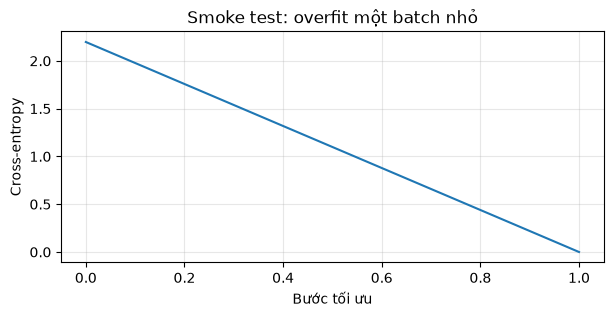

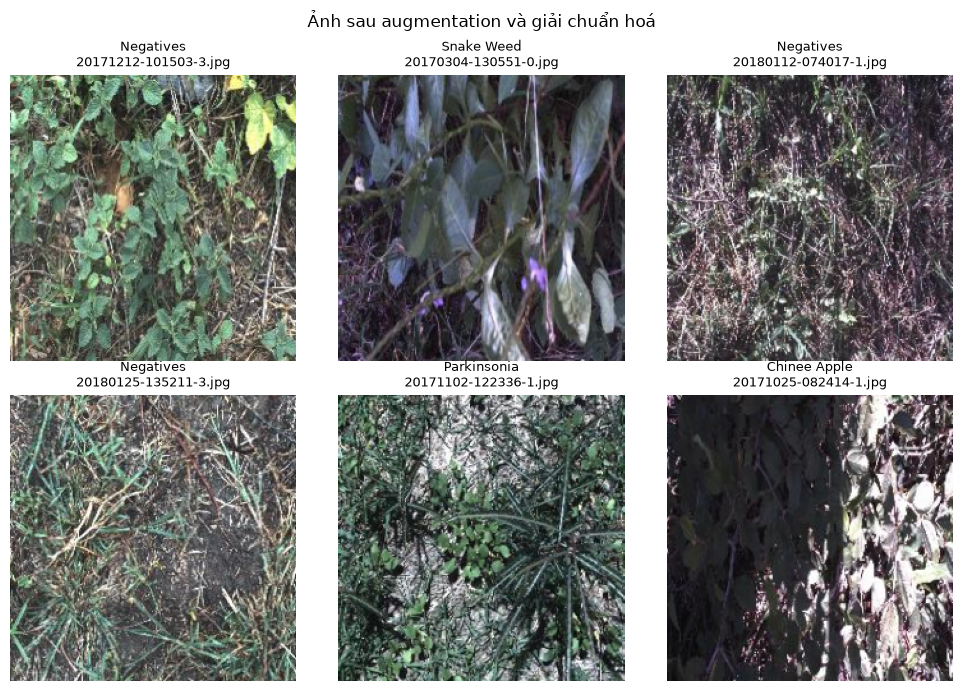

In [7]:
# TODO: kiểm tra pipeline (slide trang 59, GUIDE.md mục 1.3):
#   1) cố định seed
#   2) loss ban đầu của head mới xấp xỉ -ln(1/9) = 2.197
#   3) overfit được một batch nhỏ tới loss gần 0
#   4) vẽ vài ảnh sau augmentation (đã giải chuẩn hoá) cùng nhãn để chắc ảnh và nhãn khớp nhau

import importlib
import math
import torch.nn as nn
import train as train_utils

dataset = importlib.reload(dataset)
train_utils = importlib.reload(train_utils)
SEED = 42
train_utils.set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED} | Device: {device}")

# Tạo đúng một batch đã augmentation và giữ cố định batch này cho phép thử overfit.
train_transform = dataset.build_transforms(train=True, img_size=224, aug="basic")
smoke_loader = dataset.make_loader(
    train_df, IMAGES_DIR, train_transform, batch_size=8, train=True,
    sampler=None, num_workers=0,
)
augmented_images, batch_labels, batch_filenames = next(iter(smoke_loader))
x = augmented_images.to(device)
y = batch_labels.to(device)

# Mạng tuyến tính nhỏ là smoke test có chủ đích: chạy nhanh và cô lập lỗi data/loss/optimizer.
smoke_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 224 * 224, dataset.NUM_CLASSES),
).to(device)
head = smoke_model[-1]
nn.init.zeros_(head.weight)
nn.init.zeros_(head.bias)
criterion = nn.CrossEntropyLoss()

smoke_model.train()
assert smoke_model.training
with torch.no_grad():
    initial_loss = criterion(smoke_model(x), y).item()
expected_loss = -math.log(1.0 / dataset.NUM_CLASSES)
print(f"Loss ban đầu: {initial_loss:.4f} | kỳ vọng: {expected_loss:.4f}")
assert abs(initial_loss - expected_loss) < 0.05, "Loss ban đầu lệch xa -ln(1/9)"

# Cố tình tối ưu lặp lại cùng một batch; đây chỉ là kiểm tra pipeline, không phải train thật.
optimizer = torch.optim.AdamW(smoke_model.parameters(), lr=1e-2, weight_decay=0.0)
loss_history = []
max_steps, target_loss = 200, 1e-2
for step in range(1, max_steps + 1):
    smoke_model.train()
    optimizer.zero_grad(set_to_none=True)
    loss = criterion(smoke_model(x), y)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if loss.item() < target_loss:
        break

smoke_model.eval()
assert not smoke_model.training
with torch.inference_mode():
    final_loss = criterion(smoke_model(x), y).item()
    train_accuracy = (smoke_model(x).argmax(1) == y).float().mean().item()
print(f"Overfit batch sau {step} bước: loss={final_loss:.6f}, accuracy={train_accuracy:.1%}")
assert final_loss < 0.05 and train_accuracy == 1.0, "Chưa overfit được batch nhỏ"

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(loss_history)
ax.set(title="Smoke test: overfit một batch nhỏ", xlabel="Bước tối ưu", ylabel="Cross-entropy")
ax.grid(alpha=0.3)
plt.show()

# Giải chuẩn hoá ImageNet trước khi hiển thị ảnh đã augmentation.
mean = torch.tensor(dataset.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(dataset.IMAGENET_STD).view(3, 1, 1)
images_to_show = (augmented_images[:6].cpu() * std + mean).clamp(0, 1)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for axis, image, label, filename in zip(
    axes.flat, images_to_show, batch_labels[:6], batch_filenames[:6]
):
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(f"{dataset.CLASS_NAMES[int(label)]}\n{filename}", fontsize=9)
    axis.axis("off")
fig.suptitle("Ảnh sau augmentation và giải chuẩn hoá")
plt.tight_layout()
plt.show()

## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [9]:
# TODO: vòng lặp qua danh sách backbone, mỗi lần gọi train.run(Config(exp_id="B01", backbone=..., seed=0))
#       Gợi ý: from train import Config, run
# TODO: ghi vào bảng: tag trọng số, #params, GMAC, macro-F1 val, top-1 val, thời gian train/epoch.
# TODO: chọn 1-2 backbone đi tiếp, kèm lý do dựa trên số liệu.

import copy
import gc
import json
import importlib
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import dataset as dataset_module
import train as train_module

dataset_module = importlib.reload(dataset_module)  # tránh giữ make_loader cũ trong kernel
train_module = importlib.reload(train_module)
Config, run = train_module.Config, train_module.run

# Năm backbone đại diện cho CNN cổ điển, grouped CNN, CNN hiện đại, transformer và model nhẹ.
backbones = [
    ("B01", "resnet50"),
    ("B02", "resnext50_32x4d"),
    ("B03", "convnext_tiny"),
    ("B04", "deit_small_patch16_224"),
    ("B05", "efficientnet_b0"),
]

backbone_results = []
for exp_id, backbone_name in backbones:
    summary_path = Path("runs") / exp_id / "seed0" / "summary.json"
    if summary_path.is_file():
        print(f"{exp_id}: dùng lại kết quả đã có trong {summary_path}")
        result = json.loads(summary_path.read_text(encoding="utf-8"))
    else:
        print(f"\n=== {exp_id}: {backbone_name} ===")
        cfg = Config(
            exp_id=exp_id, backbone=backbone_name, seed=0,
            init="finetune", img_size=224, aug="basic",
            loss="ce", epochs=12, batch_size=64,
            lr_backbone=1e-4, lr_head=1e-3, weight_decay=0.05,
            # num_workers=0 ổn định trong Jupyter/Windows (không đổi dữ liệu hay recipe).
            warmup_epochs=1.0, amp=True, num_workers=0,
            images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
            save_test_predictions=False,  # Bước 1 tuyệt đối không chạy test
        )
        result = run(cfg)
    backbone_results.append(result)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

backbone_table = pd.DataFrame(backbone_results).rename(columns={
    "weight_tag": "tag trọng số",
    "params_m": "#params (M)",
    "gmac": "GMAC",
    "val_macro_f1": "macro-F1 val",
    "val_top1": "top-1 val",
    "seconds_per_epoch": "giây/epoch",
})
columns = [
    "exp_id", "backbone", "tag trọng số", "#params (M)", "GMAC",
    "best_epoch", "seed", "macro-F1 val", "top-1 val", "giây/epoch",
]
backbone_table = backbone_table[columns].sort_values("macro-F1 val", ascending=False)
backbone_table.to_csv("backbone_results.csv", index=False)
display(backbone_table.style.format({
    "#params (M)": "{:.2f}", "GMAC": "{:.3f}",
    "macro-F1 val": "{:.4f}", "top-1 val": "{:.4f}",
    "giây/epoch": "{:.1f}",
}).background_gradient(subset=["macro-F1 val"], cmap="YlGn"))

# Chọn model chất lượng cao nhất và model hiệu quả nhất trong ngưỡng 0.02 macro-F1.
best = backbone_table.iloc[0]
near_best = backbone_table[
    backbone_table["macro-F1 val"] >= best["macro-F1 val"] - 0.02
].sort_values(["GMAC", "giây/epoch"])
efficient = near_best.iloc[0]
selected = list(dict.fromkeys([best["backbone"], efficient["backbone"]]))
print("\nBackbone chọn đi tiếp:", selected)
print(
    f"- Chất lượng tốt nhất: {best['backbone']} có macro-F1 val "
    f"{best['macro-F1 val']:.4f}, top-1 {best['top-1 val']:.4f}."
)
if efficient["backbone"] != best["backbone"]:
    print(
        f"- Phương án hiệu quả: {efficient['backbone']} chỉ kém "
        f"{best['macro-F1 val'] - efficient['macro-F1 val']:.4f} macro-F1, "
        f"nhưng chỉ cần {efficient['GMAC']:.3f} GMAC và "
        f"{efficient['giây/epoch']:.1f} giây/epoch."
    )
else:
    print("- Model tốt nhất cũng là model hiệu quả nhất trong nhóm cách biệt <= 0.02 macro-F1.")


=== B01: resnet50 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
All 17,509 image files exist.
[B01] epoch 01/12 loss=1.6260 val_f1=0.2529 val_top1=0.5761 time=91.7s
[B01] epoch 02/12 loss=0.8786 val_f1=0.6431 val_top1=0.7512 time=42.0s
[B01] epoch 03/12 loss=0.5857 val_f1=0.7240 val_top1=0.8041 time=42.3s
[B01] epoch 04/12 loss=0.4519 val_f1=0.7595 val_top1=0.8252 time=42.1s
[B01] epoch 05/12 loss=0.3705 val_f1=0.7745 val_top1=0.8375 time=43.1s
[B01] epoch 06/12 loss=0.3218 val_f1=0.7799 val_top1=0.8409 time=41.9s
[B01] epoch 07/12 loss=0.2995 val_f1=0.7988 val_top1=0.8540 time=43.0s
[B01] epoch 08/12 loss=0.2684 val_f1=0.7837 val_top1=0.8458 time=45.3s
[B01] epoch 09/12 loss=0.2580 val_f1=0.7906 val_top1=0.8512 time=41.6s
[B01] epoch 10/12 loss=0.2404 val_f1=0.8020 val_top1=0.8569 time=41.8s
[B01] epoch 11/12 loss=0.2455 val_f1=0.8020 val_top1=0.8578 time=42.2s
[B01] e

d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B03] epoch 01/12 loss=0.6643 val_f1=0.8820 val_top1=0.9100 time=43.7s
[B03] epoch 02/12 loss=0.2292 val_f1=0.9247 val_top1=0.9383 time=41.3s
[B03] epoch 03/12 loss=0.1197 val_f1=0.9295 val_top1=0.9449 time=41.3s
[B03] epoch 04/12 loss=0.0881 val_f1=0.9458 val_top1=0.9574 time=41.1s
[B03] epoch 05/12 loss=0.0732 val_f1=0.9431 val_top1=0.9557 time=41.2s
[B03] epoch 06/12 loss=0.0426 val_f1=0.9433 val_top1=0.9549 time=45.2s
[B03] epoch 07/12 loss=0.0178 val_f1=0.9572 val_top1=0.9666 time=40.8s
[B03] epoch 08/12 loss=0.0121 val_f1=0.9580 val_top1=0.9674 time=41.1s
[B03] epoch 09/12 loss=0.0027 val_f1=0.9634 val_top1=0.9723 time=40.8s
[B03] epoch 10/12 loss=0.0020 val_f1=0.9654 val_top1=0.9737 time=40.9s
[B03] epoch 11/12 loss=0.0014 val_f1=0.9637 val_top1=0.9723 time=40.8s
[B03] epoch 12/12 loss=0.0010 val_f1=0.9650 val_top1=0.9734 time=40.9s

=== B04: deit_small_patch16_224 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {

d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B04] epoch 01/12 loss=0.8372 val_f1=0.8528 val_top1=0.8877 time=33.7s
[B04] epoch 02/12 loss=0.2639 val_f1=0.8999 val_top1=0.9235 time=33.4s
[B04] epoch 03/12 loss=0.1546 val_f1=0.9099 val_top1=0.9343 time=33.5s
[B04] epoch 04/12 loss=0.1128 val_f1=0.9145 val_top1=0.9394 time=33.5s
[B04] epoch 05/12 loss=0.0686 val_f1=0.9309 val_top1=0.9483 time=33.5s
[B04] epoch 06/12 loss=0.0475 val_f1=0.9426 val_top1=0.9574 time=33.7s
[B04] epoch 07/12 loss=0.0307 val_f1=0.9280 val_top1=0.9449 time=33.4s
[B04] epoch 08/12 loss=0.0175 val_f1=0.9368 val_top1=0.9543 time=33.0s
[B04] epoch 09/12 loss=0.0078 val_f1=0.9351 val_top1=0.9514 time=33.0s
[B04] epoch 10/12 loss=0.0059 val_f1=0.9426 val_top1=0.9577 time=33.0s
[B04] epoch 11/12 loss=0.0042 val_f1=0.9446 val_top1=0.9592 time=33.4s
[B04] epoch 12/12 loss=0.0035 val_f1=0.9438 val_top1=0.9586 time=33.4s

=== B05: efficientnet_b0 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_

d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B05] epoch 01/12 loss=2.0357 val_f1=0.4704 val_top1=0.5898 time=48.2s
[B05] epoch 02/12 loss=0.6743 val_f1=0.6172 val_top1=0.7167 time=43.7s
[B05] epoch 03/12 loss=0.3870 val_f1=0.6933 val_top1=0.7792 time=33.6s
[B05] epoch 04/12 loss=0.2753 val_f1=0.7163 val_top1=0.7915 time=33.7s
[B05] epoch 05/12 loss=0.1998 val_f1=0.7553 val_top1=0.8246 time=33.6s
[B05] epoch 06/12 loss=0.1625 val_f1=0.7721 val_top1=0.8352 time=33.7s
[B05] epoch 07/12 loss=0.1327 val_f1=0.7794 val_top1=0.8363 time=33.6s
[B05] epoch 08/12 loss=0.1096 val_f1=0.7922 val_top1=0.8486 time=33.8s
[B05] epoch 09/12 loss=0.0930 val_f1=0.7980 val_top1=0.8500 time=33.5s
[B05] epoch 10/12 loss=0.0863 val_f1=0.8080 val_top1=0.8552 time=33.5s
[B05] epoch 11/12 loss=0.0765 val_f1=0.8050 val_top1=0.8549 time=33.5s
[B05] epoch 12/12 loss=0.0769 val_f1=0.8040 val_top1=0.8546 time=33.5s


,exp_id,backbone,tag trọng số,#params (M),GMAC,best_epoch,seed,macro-F1 val,top-1 val,giây/epoch
2,B03,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,27.83,4.455,10,0,0.9654,0.9737,41.6
3,B04,deit_small_patch16_224,timm/deit_small_patch16_224.fb_in1k,21.67,4.241,11,0,0.9446,0.9592,33.4
1,B02,resnext50_32x4d,timm/resnext50_32x4d.a1h_in1k,23.00,4.228,10,0,0.8679,0.8983,47.3
4,B05,efficientnet_b0,timm/efficientnet_b0.ra_in1k,4.02,0.385,10,0,0.8080,0.8552,35.7
0,B01,resnet50,timm/resnet50.a1_in1k,23.53,4.087,11,0,0.8020,0.8578,46.6



Backbone chọn đi tiếp: ['convnext_tiny']
- Chất lượng tốt nhất: convnext_tiny có macro-F1 val 0.9654, top-1 0.9737.
- Model tốt nhất cũng là model hiệu quả nhất trong nhóm cách biệt <= 0.02 macro-F1.


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [10]:
# TODO: các trục A-G của GUIDE.md mục 3 (khởi tạo, augmentation, loss, sampler, LR/optimizer, EMA, ...).
# TODO: thử ít nhất một kết hợp các yếu tố tốt; so Δ với nhiễu (std).

import gc
import json
import importlib
from pathlib import Path
import dataset as dataset_module
import train as train_module

dataset_module = importlib.reload(dataset_module)
train_module = importlib.reload(train_module)
Config, run = train_module.Config, train_module.run

# Lấy backbone có macro-F1 val tốt nhất ở Bước 1; fallback chỉ dùng khi chưa có bảng Bước 1.
if "backbone_table" in globals() and len(backbone_table):
    BASE_BACKBONE = str(backbone_table.sort_values("macro-F1 val", ascending=False).iloc[0]["backbone"])
elif Path("backbone_results.csv").is_file():
    _backbone_table = pd.read_csv("backbone_results.csv")
    BASE_BACKBONE = str(_backbone_table.sort_values("macro-F1 val", ascending=False).iloc[0]["backbone"])
else:
    BASE_BACKBONE = "resnet50"
    print("Chưa thấy kết quả Bước 1; tạm dùng resnet50.")
print("Backbone dùng cho Bước 2:", BASE_BACKBONE)

# Công thức nền T00 (GUIDE mục 1.4). Mọi ablation dưới đây chỉ đổi đúng một yếu tố.
base_config = dict(
    backbone=BASE_BACKBONE, init="finetune", drop_rate=0.0,
    img_size=224, aug="basic", sampler=None, mix=None,
    loss="ce", label_smoothing=0.0,
    epochs=12, batch_size=64, lr_backbone=1e-4, lr_head=1e-3,
    weight_decay=0.05, warmup_epochs=1.0, ema_decay=None,
    amp=True, num_workers=0,
    images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
    save_test_predictions=False,
)

ablations = [
    {"exp_id": "T00", "axis": "Mốc", "difference": "Công thức nền", "changes": {}},
    {"exp_id": "T01", "axis": "B-Augmentation",
     "difference": "basic → color jitter", "changes": {"aug": "color"}},
    {"exp_id": "T02", "axis": "C-Loss",
     "difference": "CE → label smoothing ε=0.1",
     "changes": {"loss": "ls", "label_smoothing": 0.1}},
    {"exp_id": "T03", "axis": "D-Sampler",
     "difference": "shuffle → balanced sampler",
     "changes": {"sampler": "balanced"}},
    {"exp_id": "T04", "axis": "E-LR",
     "difference": "LR head 1e-3 → 1e-4 (cùng LR backbone)",
     "changes": {"lr_head": 1e-4}},
    {"exp_id": "T05", "axis": "F-EMA",
     "difference": "không EMA → EMA decay=0.999",
     "changes": {"ema_decay": 0.999}},
]

def run_or_load(exp_id, seed, changes):
    cfg = Config(exp_id=exp_id, seed=seed, **{**base_config, **changes})
    summary_path = train_module.run_dir(cfg) / "summary.json"
    config_path = train_module.run_dir(cfg) / "config.json"
    cache_matches = False
    if summary_path.is_file() and config_path.is_file():
        saved_config = json.loads(config_path.read_text(encoding="utf-8"))
        cache_matches = saved_config == vars(cfg)
    if cache_matches:
        print(f"{exp_id}/seed{seed}: dùng lại {summary_path}")
        result = json.loads(summary_path.read_text(encoding="utf-8"))
    else:
        if summary_path.is_file():
            print(f"{exp_id}/seed{seed}: config đã đổi, chạy lại thay vì dùng cache cũ.")
        print(f"\n=== {exp_id}/seed{seed} ===")
        result = run(cfg)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

# Sàng từng yếu tố với cùng seed=0.
screen_rows = []
for experiment in ablations:
    result = run_or_load(experiment["exp_id"], 0, experiment["changes"])
    screen_rows.append({**result, "axis": experiment["axis"],
                        "difference": experiment["difference"]})

screen_table = pd.DataFrame(screen_rows)
baseline_f1 = float(screen_table.loc[screen_table["exp_id"] == "T00", "val_macro_f1"].iloc[0])
screen_table["delta_vs_T00"] = screen_table["val_macro_f1"] - baseline_f1
screen_table = screen_table.sort_values("val_macro_f1", ascending=False)
screen_table.to_csv("training_ablation_results.csv", index=False)
display(screen_table[[
    "exp_id", "backbone", "axis", "difference", "seed", "best_epoch",
    "val_macro_f1", "val_top1", "delta_vs_T00", "seconds_per_epoch",
]].style.format({
    "val_macro_f1": "{:.4f}", "val_top1": "{:.4f}",
    "delta_vs_T00": "{:+.4f}", "seconds_per_epoch": "{:.1f}",
}).background_gradient(subset=["delta_vs_T00"], cmap="RdYlGn"))

# Ghép các yếu tố thắng T00. Nếu chưa có hai yếu tố dương, lấy hai ablation tốt nhất để
# kiểm tra tương tác nhưng không gọi chúng là cải thiện đã được xác nhận.
ranked_ids = screen_table.loc[screen_table["exp_id"] != "T00", "exp_id"].tolist()
positive_ids = screen_table.loc[
    (screen_table["exp_id"] != "T00") & (screen_table["delta_vs_T00"] > 0), "exp_id"
].tolist()
factor_ids = positive_ids if len(positive_ids) >= 2 else ranked_ids[:2]
combo_changes = {}
for experiment in ablations:
    if experiment["exp_id"] in factor_ids:
        combo_changes.update(experiment["changes"])
print("Các yếu tố ghép trong T10:", factor_ids, combo_changes)

# T10 là cấu hình kết hợp; chạy seed 0 rồi bổ sung seed 1–2 cho cả T00 và T10.
combo_seed0 = run_or_load("T10", 0, combo_changes)
seed_rows = []
for exp_id, changes in [("T00", {}), ("T10", combo_changes)]:
    for seed in (0, 1, 2):
        result = (combo_seed0 if exp_id == "T10" and seed == 0
                  else run_or_load(exp_id, seed, changes))
        seed_rows.append(result)

seed_table = pd.DataFrame(seed_rows)
seed_summary = seed_table.groupby("exp_id").agg(
    n_seeds=("seed", "count"),
    macro_f1_mean=("val_macro_f1", "mean"),
    macro_f1_std=("val_macro_f1", lambda values: values.std(ddof=1)),
    top1_mean=("val_top1", "mean"),
    top1_std=("val_top1", lambda values: values.std(ddof=1)),
).reset_index()
seed_summary.to_csv("training_seed_summary.csv", index=False)
display(seed_summary.style.format({
    "macro_f1_mean": "{:.4f}", "macro_f1_std": "{:.4f}",
    "top1_mean": "{:.4f}", "top1_std": "{:.4f}",
}))

base_stats = seed_summary.set_index("exp_id").loc["T00"]
combo_stats = seed_summary.set_index("exp_id").loc["T10"]
delta = combo_stats["macro_f1_mean"] - base_stats["macro_f1_mean"]
noise = max(base_stats["macro_f1_std"], combo_stats["macro_f1_std"])
print(
    f"T10 − T00: Δ macro-F1 = {delta:+.4f}; "
    f"mức nhiễu bảo thủ max(std) = {noise:.4f}."
)
if delta > noise:
    conclusion = "Mức tăng lớn hơn std; có tín hiệu cải thiện thực nghiệm."
elif delta < -noise:
    conclusion = "Mức giảm lớn hơn std; cấu hình kết hợp có tín hiệu kém hơn T00."
else:
    conclusion = "Chênh lệch không lớn hơn std; chưa thể phân biệt T10 và T00."
print(conclusion)

best_recipe = {
    "backbone": BASE_BACKBONE, "factors": factor_ids, "changes": combo_changes,
    "delta_macro_f1_mean": float(delta), "noise_max_std": float(noise),
    "conclusion": conclusion,
}
Path("best_training_recipe.json").write_text(
    json.dumps(best_recipe, ensure_ascii=False, indent=2), encoding="utf-8"
)

Backbone dùng cho Bước 2: convnext_tiny

=== T00/seed0 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
All 17,509 image files exist.


d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00] epoch 01/12 loss=0.6643 val_f1=0.8820 val_top1=0.9100 time=70.6s
[T00] epoch 02/12 loss=0.2292 val_f1=0.9247 val_top1=0.9383 time=40.6s
[T00] epoch 03/12 loss=0.1197 val_f1=0.9295 val_top1=0.9449 time=41.1s
[T00] epoch 04/12 loss=0.0881 val_f1=0.9458 val_top1=0.9574 time=41.1s
[T00] epoch 05/12 loss=0.0732 val_f1=0.9431 val_top1=0.9557 time=40.5s
[T00] epoch 06/12 loss=0.0426 val_f1=0.9433 val_top1=0.9549 time=40.4s
[T00] epoch 07/12 loss=0.0178 val_f1=0.9572 val_top1=0.9666 time=40.3s
[T00] epoch 08/12 loss=0.0121 val_f1=0.9580 val_top1=0.9674 time=40.5s
[T00] epoch 09/12 loss=0.0027 val_f1=0.9634 val_top1=0.9723 time=40.4s
[T00] epoch 10/12 loss=0.0020 val_f1=0.9654 val_top1=0.9737 time=40.5s
[T00] epoch 11/12 loss=0.0014 val_f1=0.9637 val_top1=0.9723 time=40.5s
[T00] epoch 12/12 loss=0.0010 val_f1=0.9650 val_top1=0.9734 time=40.6s

=== T01/seed0 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_val': 0, 't

d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T01] epoch 01/12 loss=0.7053 val_f1=0.7326 val_top1=0.8323 time=65.9s
[T01] epoch 02/12 loss=0.2669 val_f1=0.8807 val_top1=0.9069 time=66.0s
[T01] epoch 03/12 loss=0.1466 val_f1=0.9059 val_top1=0.9309 time=66.0s
[T01] epoch 04/12 loss=0.1047 val_f1=0.9377 val_top1=0.9517 time=66.0s
[T01] epoch 05/12 loss=0.0704 val_f1=0.9380 val_top1=0.9514 time=66.5s
[T01] epoch 06/12 loss=0.0549 val_f1=0.9358 val_top1=0.9492 time=66.2s
[T01] epoch 07/12 loss=0.0274 val_f1=0.9579 val_top1=0.9669 time=66.2s
[T01] epoch 08/12 loss=0.0154 val_f1=0.9586 val_top1=0.9677 time=66.1s
[T01] epoch 09/12 loss=0.0090 val_f1=0.9610 val_top1=0.9689 time=66.3s
[T01] epoch 10/12 loss=0.0052 val_f1=0.9636 val_top1=0.9717 time=67.3s
[T01] epoch 11/12 loss=0.0025 val_f1=0.9660 val_top1=0.9734 time=68.0s
[T01] epoch 12/12 loss=0.0032 val_f1=0.9660 val_top1=0.9734 time=66.7s

=== T02/seed0 ===
Split check: PASS
Image counts: {'train': 10501, 'val': 3501, 'test': 3507, 'total': 17509}
Pairwise overlap: {'train_val': 0, 't

...

d:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\train.py:198: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T10] epoch 01/12 loss=1.0104 val_f1=0.1710 val_top1=0.1720 time=67.1s
[T10] epoch 02/12 loss=0.6397 val_f1=0.5053 val_top1=0.5136 time=66.7s
[T10] epoch 03/12 loss=0.5827 val_f1=0.7678 val_top1=0.7818 time=72.6s
[T10] epoch 04/12 loss=0.5539 val_f1=0.8739 val_top1=0.8866 time=73.1s
[T10] epoch 05/12 loss=0.5313 val_f1=0.9121 val_top1=0.9246 time=69.5s
[T10] epoch 06/12 loss=0.5117 val_f1=0.9346 val_top1=0.9454 time=66.5s
[T10] epoch 07/12 loss=0.5083 val_f1=0.9434 val_top1=0.9534 time=66.6s
[T10] epoch 08/12 loss=0.4990 val_f1=0.9527 val_top1=0.9614 time=66.5s
[T10] epoch 09/12 loss=0.4961 val_f1=0.9589 val_top1=0.9666 time=66.6s
[T10] epoch 10/12 loss=0.4946 val_f1=0.9588 val_top1=0.9663 time=66.7s
[T10] epoch 11/12 loss=0.4912 val_f1=0.9609 val_top1=0.9683 time=66.7s
[T10] epoch 12/12 loss=0.4913 val_f1=0.9640 val_top1=0.9709 time=66.8s


,exp_id,n_seeds,macro_f1_mean,macro_f1_std,top1_mean,top1_std
0,T00,3,0.9654,0.0017,0.9735,0.0006
1,T10,3,0.9636,0.0014,0.9708,0.0007


T10 − T00: Δ macro-F1 = -0.0018; mức nhiễu bảo thủ max(std) = 0.0017.
Mức giảm lớn hơn std; cấu hình kết hợp có tín hiệu kém hơn T00.


440

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

Checkpoint được chọn hoàn toàn theo val: T00


,exp_id,method,K,macro_f1_val,top1_val,ece_val,nll_val,gpu,dtype,batch,img_size,p50_ms,p95_ms,p99_ms,images_per_s,relative_cost,warmup,iterations,includes_preprocessing
4,I04,single-view resolution 256,1,0.9713,0.9786,0.0139,0.0980,NVIDIA GeForce RTX 5060 Ti,fp32,1,256,3.58,3.77,3.91,279.122996,0.87×,10,100,False
5,I05,"ensemble probability, seed 0/1/2",3,0.9700,0.9766,0.0083,0.0868,NVIDIA GeForce RTX 5060 Ti,fp32,1,224,11.66,12.72,14.70,85.735720,2.83×,10,100,False
2,I02,"multi-scale [192, 224, 256] (prob mean)",3,0.9685,0.9760,0.0108,0.0922,NVIDIA GeForce RTX 5060 Ti,fp32,1,"[192, 224, 256]",11.05,12.10,12.53,90.470719,2.68×,10,100,False
3,I03,"multi-scale [192, 224, 256] (logit mean)",3,0.9675,0.9757,0.0149,0.0985,NVIDIA GeForce RTX 5060 Ti,fp32,1,"[192, 224, 256]",11.05,12.10,12.53,90.470719,2.68×,10,100,False
1,I01,TTA identity + hflip (prob mean),2,0.9659,0.9743,0.0137,0.1019,NVIDIA GeForce RTX 5060 Ti,fp32,1,224,7.54,9.32,9.83,132.676144,1.83×,10,100,False
0,I00,1-view 224,1,0.9654,0.9737,0.0160,0.1122,NVIDIA GeForce RTX 5060 Ti,fp32,1,224,4.13,4.37,6.14,242.295018,1.00×,10,100,False
6,I06,temperature scaling T=1.639,1,0.9654,0.9737,0.0051,0.0904,NVIDIA GeForce RTX 5060 Ti,fp32,1,224,4.13,4.37,6.14,242.295018,1.00×,10,100,False
7,I07,FP16 1-view,1,0.9654,0.9737,0.0161,0.1123,NVIDIA GeForce RTX 5060 Ti,fp16,1,224,4.20,4.46,4.55,237.896991,1.02×,10,100,False


,exp_id,gpu,dtype,batch,img_size,p50_ms,p95_ms,p99_ms,images_per_s,relative_cost,warmup,iterations,includes_preprocessing
8,I00_batch32,NVIDIA GeForce RTX 5060 Ti,fp32,32,224,41.361,42.45245,42.577862,773.675685,NaN,10,50,False


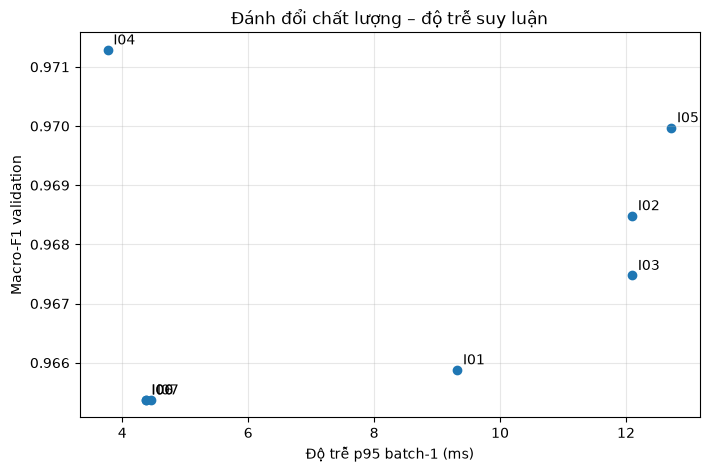

Phương pháp suy luận chọn trên val: {'training_exp': 'T00', 'inference_exp': 'I04', 'method': 'single-view resolution 256', 'macro_f1_val': 0.9712846755225439, 'top1_val': 0.9785775492716366, 'ece_val': 0.013865003234078176, 'p95_ms': 3.770240012090653, 'temperature': 1.6392949155352423}


In [11]:
# TODO: TTA lật, multi-crop/scale, dò độ phân giải, gộp xác suất vs logit, ensemble, EMA/soup,
#       temperature scaling (T khớp trên VAL), gộp BN/FP16  (starter/inference.py)
# TODO: độ trễ p50/p95/p99 bằng starter/benchmark.py: warmup, synchronize, >= 50 lần

import copy
import gc
import json
import importlib
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import dataset as dataset_module
import model as model_module
import inference as inference_module
import benchmark as benchmark_module
import train as train_module

dataset_module = importlib.reload(dataset_module)
model_module = importlib.reload(model_module)
inference_module = importlib.reload(inference_module)
benchmark_module = importlib.reload(benchmark_module)
train_module = importlib.reload(train_module)
repo_root = Path(train_module.__file__).resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
REPO_DIR = str(repo_root)  # để hai cell eval.py bên dưới chạy đúng cả khi cwd là starter/
from eval import compute_metrics, save_predictions

# Kết quả notebook nằm cạnh notebook (starter/) khi Jupyter được mở từ thư mục đó.
artifact_candidates = [Path.cwd(), Path(train_module.__file__).resolve().parent]
artifact_root = next(
    (path for path in artifact_candidates if (path / "training_seed_summary.csv").is_file()),
    None,
)
if artifact_root is None:
    raise FileNotFoundError("Chưa có training_seed_summary.csv; hãy chạy xong Bước 2 trước.")

training_summary = pd.read_csv(artifact_root / "training_seed_summary.csv")
BEST_TRAIN_EXP = str(training_summary.sort_values("macro_f1_mean", ascending=False).iloc[0]["exp_id"])
print("Checkpoint được chọn hoàn toàn theo val:", BEST_TRAIN_EXP)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_checkpoint_model(exp_id, seed):
    run_path = artifact_root / "runs" / exp_id / f"seed{seed}"
    config_path, checkpoint_path = run_path / "config.json", run_path / "best.pt"
    if not config_path.is_file() or not checkpoint_path.is_file():
        raise FileNotFoundError(f"Thiếu checkpoint/config: {run_path}")
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    network = model_module.build_model(
        cfg["backbone"], pretrained=False, num_classes=dataset_module.NUM_CLASSES,
        drop_rate=cfg.get("drop_rate", 0.0), init="scratch",
    ).to(device)
    try:
        state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(checkpoint_path, map_location=device)
    network.load_state_dict(state)
    return network.eval(), cfg

base_model, inference_cfg = load_checkpoint_model(BEST_TRAIN_EXP, 0)
_, val_df, _ = dataset_module.load_split(inference_cfg["labels_dir"], inference_cfg["fold"])
eval_transform = dataset_module.build_transforms(False, inference_cfg["img_size"], "basic")
val_loader = dataset_module.make_loader(
    val_df, inference_cfg["images_dir"], eval_transform, batch_size=64,
    train=False, num_workers=0,
)

# I00 và I01: 1-view và TTA lật ngang K=2.
val_filenames, y_val, logits_identity = inference_module.predict_logits(
    base_model, val_loader, device, inference_module.view_identity
)
flip_filenames, flip_labels, logits_flip = inference_module.predict_logits(
    base_model, val_loader, device, inference_module.view_hflip
)
assert val_filenames == flip_filenames and np.array_equal(y_val, flip_labels)
probs_identity = inference_module.aggregate_views([logits_identity], "prob")
probs_flip = inference_module.aggregate_views([logits_identity, logits_flip], "prob")

method_outputs = [
    {"exp_id": "I00", "method": "1-view 224", "k": 1, "probs": probs_identity},
    {"exp_id": "I01", "method": "TTA identity + hflip (prob mean)",
     "k": 2, "probs": probs_flip},
]

# I02/I03/I04: multi-scale và so gộp probability với logit; bỏ kích thước model không hỗ trợ.
scale_logits = {224: logits_identity}
for size in (192, 256):
    try:
        names, labels, logits = inference_module.predict_logits(
            base_model, val_loader, device,
            view=lambda images, target=size: F.interpolate(
                images, size=(target, target), mode="bilinear", align_corners=False
            ),
        )
        assert names == val_filenames and np.array_equal(labels, y_val)
        scale_logits[size] = logits
    except (RuntimeError, AssertionError, ValueError) as error:
        print(f"Bỏ scale {size} cho {inference_cfg['backbone']}: {error}")

if len(scale_logits) >= 2:
    ordered_scales = sorted(scale_logits)
    logits_views = [scale_logits[size] for size in ordered_scales]
    method_outputs.extend([
        {"exp_id": "I02", "method": f"multi-scale {ordered_scales} (prob mean)",
         "k": len(ordered_scales),
         "probs": inference_module.aggregate_views(logits_views, "prob")},
        {"exp_id": "I03", "method": f"multi-scale {ordered_scales} (logit mean)",
         "k": len(ordered_scales),
         "probs": inference_module.aggregate_views(logits_views, "logit")},
    ])
if 256 in scale_logits:
    method_outputs.append({
        "exp_id": "I04", "method": "single-view resolution 256", "k": 1,
        "probs": inference_module.aggregate_views([scale_logits[256]], "prob"),
    })

# I05: ensemble xác suất của ba seed, nạp lần lượt để không giữ ba model trên GPU.
ensemble_members = []
for seed in (0, 1, 2):
    if seed == 0:
        member_probs = probs_identity
    else:
        member_model, _ = load_checkpoint_model(BEST_TRAIN_EXP, seed)
        names, labels, member_logits = inference_module.predict_logits(
            member_model, val_loader, device
        )
        assert names == val_filenames and np.array_equal(labels, y_val)
        member_probs = inference_module.aggregate_views([member_logits], "prob")
        del member_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    ensemble_members.append(member_probs)
method_outputs.append({
    "exp_id": "I05", "method": "ensemble probability, seed 0/1/2", "k": 3,
    "probs": inference_module.ensemble_probs(ensemble_members),
})

# I06: temperature scaling khớp duy nhất trên validation; top-1 không đổi.
temperature = inference_module.fit_temperature(logits_identity, y_val)
method_outputs.append({
    "exp_id": "I06", "method": f"temperature scaling T={temperature:.3f}",
    "k": 1, "probs": inference_module.apply_temperature(logits_identity, temperature),
})

# I07: FP16 thật trên GPU; nếu phần cứng không hỗ trợ thì ghi rõ và bỏ qua.
if device.type == "cuda":
    try:
        fp16_model = copy.deepcopy(base_model).half().eval()
        names, labels, fp16_logits = inference_module.predict_logits(
            fp16_model, val_loader, device, view=lambda images: images.half()
        )
        assert names == val_filenames and np.array_equal(labels, y_val)
        method_outputs.append({
            "exp_id": "I07", "method": "FP16 1-view", "k": 1,
            "probs": inference_module.aggregate_views([fp16_logits], "prob"),
        })
        del fp16_model
    except RuntimeError as error:
        print("Bỏ FP16:", error)

# I08: fuse Conv-BN khi kiến trúc có BatchNorm; ConvNeXt/ViT dùng LayerNorm sẽ được bỏ qua.
bn_count = sum(isinstance(module, torch.nn.BatchNorm2d) for module in base_model.modules())
if bn_count:
    fused_model = inference_module.fuse_conv_bn(base_model).to(device).eval()
    names, labels, fused_logits = inference_module.predict_logits(fused_model, val_loader, device)
    max_fuse_error = float(np.max(np.abs(fused_logits - logits_identity)))
    print(f"Fuse {bn_count} BatchNorm; max |Δlogit|={max_fuse_error:.3e}")
    method_outputs.append({
        "exp_id": "I08", "method": "fused Conv-BN", "k": 1,
        "probs": inference_module.aggregate_views([fused_logits], "prob"),
    })

# Tính metric chính thức và lưu dự đoán validation của từng phương pháp.
metric_rows = []
for item in method_outputs:
    metrics = compute_metrics(y_val, item["probs"].argmax(1), item["probs"])
    metric_rows.append({
        "exp_id": item["exp_id"], "method": item["method"], "K": item["k"],
        "macro_f1_val": metrics["macro_f1"], "top1_val": metrics["top1"],
        "ece_val": metrics["ece"], "nll_val": metrics["nll"],
    })
    save_predictions(
        artifact_root / "predictions" / f"{item['exp_id']}_seed0_val.csv",
        val_filenames, y_val, item["probs"],
    )

# Độ trễ forward thuần: warmup=10, 100 lần, benchmark.py đồng bộ CUDA hai phía.
bench_device = "cuda" if torch.cuda.is_available() else "cpu"
bench_common = dict(batch_size=1, img_size=224, device=bench_device, warmup=10, iters=100)
latency_by_id = {}
latency_by_id["I00"] = benchmark_module.latency_report(base_model, dtype="fp32", **bench_common)
latency_by_id["I01"] = benchmark_module.tta_latency(base_model, 2, dtype="fp32", **bench_common)
if "I02" in {item['exp_id'] for item in method_outputs}:
    # Đo đúng từng forward ở 192/224/256; không lấy K × thời gian 224 làm đại diện.
    scale_samples = [
        torch.randn(1, 3, size, size, device=device) for size in sorted(scale_logits)
    ]
    def multiscale_forward():
        with torch.inference_mode():
            return [base_model(sample) for sample in scale_samples]
    scale_stats = benchmark_module.bench(
        multiscale_forward, warmup=10, iters=100,
        sync=torch.cuda.synchronize if device.type == "cuda" else None,
    )
    scale_stats.update({
        "gpu": torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU",
        "dtype": "fp32", "batch": 1, "img_size": str(sorted(scale_logits)),
        "images_per_s": 1.0 / (scale_stats["p50"] / 1000.0),
        "includes_preprocessing": False, "k_views": len(scale_logits),
    })
    latency_by_id["I02"] = scale_stats
    latency_by_id["I03"] = latency_by_id["I02"].copy()
if "I04" in {item['exp_id'] for item in method_outputs}:
    latency_by_id["I04"] = benchmark_module.latency_report(
        base_model, batch_size=1, img_size=256, dtype="fp32", device=bench_device,
        warmup=10, iters=100,
    )
latency_by_id["I05"] = benchmark_module.tta_latency(base_model, 3, dtype="fp32", **bench_common)
latency_by_id["I06"] = latency_by_id["I00"].copy()
if "I07" in {item['exp_id'] for item in method_outputs}:
    latency_by_id["I07"] = benchmark_module.latency_report(base_model, dtype="fp16", **bench_common)
if "I08" in {item['exp_id'] for item in method_outputs}:
    latency_by_id["I08"] = benchmark_module.latency_report(fused_model, dtype="fp32", **bench_common)

# Thêm batch 32 để báo cáo thông lượng theo GUIDE mục 4.1.
throughput_report = benchmark_module.latency_report(
    base_model, batch_size=32, img_size=224, dtype="fp32", device=bench_device,
    warmup=10, iters=50,
)
latency_rows = []
base_p50 = latency_by_id["I00"]["p50"]
for exp_id, report in latency_by_id.items():
    latency_rows.append({
        "exp_id": exp_id, "gpu": report["gpu"], "dtype": report["dtype"],
        "batch": report["batch"], "img_size": report["img_size"],
        "p50_ms": report["p50"], "p95_ms": report["p95"],
        "p99_ms": report["p99"], "images_per_s": report["images_per_s"],
        "relative_cost": report["p50"] / base_p50,
        "warmup": 10, "iterations": report["n"], "includes_preprocessing": False,
    })
latency_rows.append({
    "exp_id": "I00_batch32", "gpu": throughput_report["gpu"],
    "dtype": throughput_report["dtype"], "batch": 32, "img_size": 224,
    "p50_ms": throughput_report["p50"], "p95_ms": throughput_report["p95"],
    "p99_ms": throughput_report["p99"],
    "images_per_s": throughput_report["images_per_s"], "relative_cost": np.nan,
    "warmup": 10, "iterations": throughput_report["n"],
    "includes_preprocessing": False,
})

inference_table = pd.DataFrame(metric_rows).merge(
    pd.DataFrame(latency_rows).query("batch == 1"), on="exp_id", how="left"
).sort_values("macro_f1_val", ascending=False)
latency_table = pd.DataFrame(latency_rows)
inference_table.to_csv(artifact_root / "inference_results.csv", index=False)
latency_table.to_csv(artifact_root / "latency_results.csv", index=False)
display(inference_table.style.format({
    "macro_f1_val": "{:.4f}", "top1_val": "{:.4f}", "ece_val": "{:.4f}",
    "nll_val": "{:.4f}", "p50_ms": "{:.2f}", "p95_ms": "{:.2f}",
    "p99_ms": "{:.2f}", "relative_cost": "{:.2f}×",
}).background_gradient(subset=["macro_f1_val"], cmap="YlGn"))
display(latency_table.tail(1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(inference_table["p95_ms"], inference_table["macro_f1_val"])
for _, row in inference_table.iterrows():
    ax.annotate(row["exp_id"], (row["p95_ms"], row["macro_f1_val"]),
                xytext=(4, 4), textcoords="offset points")
ax.set(xlabel="Độ trễ p95 batch-1 (ms)", ylabel="Macro-F1 validation",
       title="Đánh đổi chất lượng – độ trễ suy luận")
ax.grid(alpha=0.3)
plt.show()

best_inference = inference_table.sort_values(
    ["macro_f1_val", "p95_ms"], ascending=[False, True]
).iloc[0]
selected_inference = {
    "training_exp": BEST_TRAIN_EXP, "inference_exp": best_inference["exp_id"],
    "method": best_inference["method"],
    "macro_f1_val": float(best_inference["macro_f1_val"]),
    "top1_val": float(best_inference["top1_val"]),
    "ece_val": float(best_inference["ece_val"]),
    "p95_ms": float(best_inference["p95_ms"]),
    "temperature": float(temperature),
}
(artifact_root / "best_inference.json").write_text(
    json.dumps(selected_inference, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Phương pháp suy luận chọn trên val:", selected_inference)

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [12]:
# TODO: chạy chung kết và mốc, mỗi seed, ví dụ:
#   for seed in (0, 1, 2):
#       run(Config(exp_id="F01", ..., seed=seed, save_test_predictions=True))
#       run(Config(exp_id="T00", seed=seed, save_test_predictions=True))
# Với suy luận (TTA/ensemble/temperature scaling), tự ghi predictions/F01_seed<k>_test.csv
# bằng eval.save_predictions(...) từ xác suất cuối cùng; thêm F01uncal_* nếu muốn chấm I4(a).

import copy
import gc
import json
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import dataset as dataset_module
import model as model_module
import inference as inference_module
import train as train_module

dataset_module = importlib.reload(dataset_module)
model_module = importlib.reload(model_module)
inference_module = importlib.reload(inference_module)
train_module = importlib.reload(train_module)
repo_root = Path(train_module.__file__).resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
REPO_DIR = str(repo_root)  # để hai cell eval.py bên dưới chạy đúng cả khi cwd là starter/
from eval import check_against_csv, compute_metrics, read_pred, save_predictions

# Chỉ được vào cell này sau khi best_inference.json đã được chốt hoàn toàn trên validation.
artifact_candidates = [Path.cwd(), Path(train_module.__file__).resolve().parent]
artifact_root = next(
    (path for path in artifact_candidates if (path / "best_inference.json").is_file()),
    None,
)
if artifact_root is None:
    raise FileNotFoundError("Chưa có best_inference.json; hãy hoàn tất Bước 3 trước.")
selected = json.loads((artifact_root / "best_inference.json").read_text(encoding="utf-8"))
FINAL_TRAIN_EXP = str(selected["training_exp"])
FINAL_INFERENCE_EXP = str(selected["inference_exp"])
FINAL_METHOD = str(selected["method"])
SEEDS = (0, 1, 2)
print("CẤU HÌNH ĐÃ KHÓA TRÊN VAL:", selected)
print("Từ đây không được đổi cấu hình dựa trên kết quả test.")

# Manifest bảo vệ giao thức: nếu chạy lại, cấu hình phải giống hệt lần chung kết đầu tiên.
predictions_dir = Path("predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)
protocol_path = predictions_dir / "final_protocol.json"
protocol = {
    "final_exp_id": "F01", "training_exp": FINAL_TRAIN_EXP,
    "inference_exp": FINAL_INFERENCE_EXP, "method": FINAL_METHOD,
    "baseline": "T00 + I00", "seeds": list(SEEDS),
    "save_test_predictions": True,
}
if protocol_path.is_file():
    old_protocol = json.loads(protocol_path.read_text(encoding="utf-8"))
    if old_protocol != protocol:
        raise RuntimeError(
            "final_protocol.json đã tồn tại với cấu hình khác; không được chọn lại sau khi xem test."
        )
else:
    protocol_path.write_text(
        json.dumps(protocol, ensure_ascii=False, indent=2), encoding="utf-8"
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_final_model(exp_id, seed):
    run_path = artifact_root / "runs" / exp_id / f"seed{seed}"
    config_path, checkpoint_path = run_path / "config.json", run_path / "best.pt"
    if not config_path.is_file() or not checkpoint_path.is_file():
        raise FileNotFoundError(f"Thiếu checkpoint/config cho {exp_id}/seed{seed}: {run_path}")
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    network = model_module.build_model(
        cfg["backbone"], pretrained=False, num_classes=dataset_module.NUM_CLASSES,
        drop_rate=cfg.get("drop_rate", 0.0), init="scratch",
    ).to(device)
    try:
        state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(checkpoint_path, map_location=device)
    network.load_state_dict(state)
    return network.eval(), cfg

def checked_existing_prediction(path, test_csv):
    if not path.is_file():
        return False
    prediction = read_pred(str(path))
    check_against_csv(prediction, str(test_csv), what="test")
    print(f"Giữ nguyên file test đã tồn tại, KHÔNG chạy lại: {path}")
    return True

def probabilities_for_locked_method(network, loader, method_id, temperature):
    # I04 là đúng một view 256; không chạy thừa view 224 trên test.
    if method_id == "I04":
        filenames, labels, logits_256 = inference_module.predict_logits(
            network, loader, device,
            view=lambda images: F.interpolate(
                images, size=(256, 256), mode="bilinear", align_corners=False
            ),
        )
        probs = inference_module.aggregate_views([logits_256], "prob")
        return filenames, labels, probs, probs
    # I07 cũng là một view; chạy trực tiếp FP16 thay vì chạy thêm FP32.
    if method_id == "I07":
        if device.type != "cuda":
            raise RuntimeError("I07 FP16 cần CUDA")
        half_model = copy.deepcopy(network).half().eval()
        filenames, labels, logits_half = inference_module.predict_logits(
            half_model, loader, device, view=lambda images: images.half()
        )
        del half_model
        probs = inference_module.aggregate_views([logits_half], "prob")
        return filenames, labels, probs, probs
    filenames, labels, logits_identity = inference_module.predict_logits(
        network, loader, device, inference_module.view_identity
    )
    uncalibrated = inference_module.aggregate_views([logits_identity], "prob")
    if method_id == "I00":
        return filenames, labels, uncalibrated, uncalibrated
    if method_id == "I01":
        names_flip, labels_flip, logits_flip = inference_module.predict_logits(
            network, loader, device, inference_module.view_hflip
        )
        assert filenames == names_flip and np.array_equal(labels, labels_flip)
        probs = inference_module.aggregate_views([logits_identity, logits_flip], "prob")
        return filenames, labels, probs, uncalibrated
    if method_id in {"I02", "I03"}:
        logits_views = []
        for size in (192, 224, 256):
            if size == 224:
                logits_views.append(logits_identity)
            else:
                names, y_view, logits = inference_module.predict_logits(
                    network, loader, device,
                    view=lambda images, target=size: F.interpolate(
                        images, size=(target, target), mode="bilinear", align_corners=False
                    ),
                )
                assert filenames == names and np.array_equal(labels, y_view)
                logits_views.append(logits)
        space = "prob" if method_id == "I02" else "logit"
        return filenames, labels, inference_module.aggregate_views(logits_views, space), uncalibrated
    if method_id == "I06":
        calibrated = inference_module.apply_temperature(logits_identity, temperature)
        return filenames, labels, calibrated, uncalibrated
    raise NotImplementedError(
        f"Final method {method_id} chưa được ánh xạ theo đúng phép suy luận đã chọn trên val"
    )

# Kiểm tra đủ checkpoint trước khi mở test, tránh chạy dở do thiếu seed.
for exp_id in {"T00", FINAL_TRAIN_EXP}:
    for seed in SEEDS:
        run_path = artifact_root / "runs" / exp_id / f"seed{seed}"
        if not (run_path / "best.pt").is_file() or not (run_path / "config.json").is_file():
            raise FileNotFoundError(f"Chưa đủ checkpoint: {run_path}")

# Đây là điểm duy nhất mở TEST. Mỗi file đã có sẽ được xác minh rồi giữ nguyên.
for seed in SEEDS:
    baseline_path = predictions_dir / f"T00_seed{seed}_test.csv"
    final_path = predictions_dir / f"F01_seed{seed}_test.csv"

    baseline_model, baseline_cfg = load_final_model("T00", seed)
    _, _, baseline_test_df = dataset_module.load_split(
        baseline_cfg["labels_dir"], baseline_cfg["fold"]
    )
    baseline_test_csv = Path(baseline_cfg["labels_dir"]) / f"test_subset{baseline_cfg['fold']}.csv"
    baseline_transform = dataset_module.build_transforms(
        False, baseline_cfg["img_size"], "basic"
    )
    baseline_loader = dataset_module.make_loader(
        baseline_test_df, baseline_cfg["images_dir"], baseline_transform,
        batch_size=64, train=False, num_workers=0,
    )

    baseline_exists = checked_existing_prediction(baseline_path, baseline_test_csv)
    if not baseline_exists:
        filenames, labels, logits = inference_module.predict_logits(
            baseline_model, baseline_loader, device
        )
        baseline_probs = inference_module.aggregate_views([logits], "prob")
        save_predictions(baseline_path, filenames, labels, baseline_probs)
        print("Đã chạy test mốc đúng một lần:", baseline_path)

    final_model = baseline_model
    final_cfg = baseline_cfg
    final_loader = baseline_loader
    final_test_csv = baseline_test_csv
    if FINAL_TRAIN_EXP != "T00":
        final_model, final_cfg = load_final_model(FINAL_TRAIN_EXP, seed)
        _, _, final_test_df = dataset_module.load_split(final_cfg["labels_dir"], final_cfg["fold"])
        final_test_csv = Path(final_cfg["labels_dir"]) / f"test_subset{final_cfg['fold']}.csv"
        final_transform = dataset_module.build_transforms(False, final_cfg["img_size"], "basic")
        final_loader = dataset_module.make_loader(
            final_test_df, final_cfg["images_dir"], final_transform,
            batch_size=64, train=False, num_workers=0,
        )

    final_exists = checked_existing_prediction(final_path, final_test_csv)
    if not final_exists:
        filenames, labels, final_probs, uncalibrated_probs = probabilities_for_locked_method(
            final_model, final_loader, FINAL_INFERENCE_EXP, float(selected.get("temperature", 1.0))
        )
        save_predictions(final_path, filenames, labels, final_probs)
        print("Đã chạy test chung kết đúng một lần:", final_path)
        if FINAL_INFERENCE_EXP == "I06":
            uncal_path = predictions_dir / f"F01uncal_seed{seed}_test.csv"
            if not uncal_path.exists():
                save_predictions(uncal_path, filenames, labels, uncalibrated_probs)

    del baseline_model, final_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Chỉ sau khi đủ sáu file test mới tính bảng kết quả; không dùng bảng này để đổi cấu hình.
final_rows = []
for tag in ("T00", "F01"):
    for seed in SEEDS:
        path = predictions_dir / f"{tag}_seed{seed}_test.csv"
        prediction = read_pred(str(path))
        metrics = compute_metrics(
            prediction.y_true, prediction.y_pred, prediction.probs
        )
        final_rows.append({
            "exp_id": tag, "seed": seed, "macro_f1_test": metrics["macro_f1"],
            "top1_test": metrics["top1"], "ece_test": metrics["ece"],
        })
final_test_table = pd.DataFrame(final_rows)
final_test_summary = final_test_table.groupby("exp_id").agg(
    macro_f1_mean=("macro_f1_test", "mean"),
    macro_f1_std=("macro_f1_test", lambda values: values.std(ddof=1)),
    top1_mean=("top1_test", "mean"),
    top1_std=("top1_test", lambda values: values.std(ddof=1)),
    ece_mean=("ece_test", "mean"),
).reset_index()
final_test_table.to_csv(artifact_root / "final_test_per_seed.csv", index=False)
final_test_summary.to_csv(artifact_root / "final_test_summary.csv", index=False)
display(final_test_table.style.format({
    "macro_f1_test": "{:.4f}", "top1_test": "{:.4f}", "ece_test": "{:.4f}",
}))
display(final_test_summary.style.format({
    "macro_f1_mean": "{:.4f}", "macro_f1_std": "{:.4f}",
    "top1_mean": "{:.4f}", "top1_std": "{:.4f}", "ece_mean": "{:.4f}",
}))

CẤU HÌNH ĐÃ KHÓA TRÊN VAL: {'training_exp': 'T00', 'inference_exp': 'I04', 'method': 'single-view resolution 256', 'macro_f1_val': 0.9712846755225439, 'top1_val': 0.9785775492716366, 'ece_val': 0.013865003234078176, 'p95_ms': 3.770240012090653, 'temperature': 1.6392949155352423}
Từ đây không được đổi cấu hình dựa trên kết quả test.
Đã chạy test mốc đúng một lần: predictions\T00_seed0_test.csv
Đã chạy test chung kết đúng một lần: predictions\F01_seed0_test.csv
Đã chạy test mốc đúng một lần: predictions\T00_seed1_test.csv
Đã chạy test chung kết đúng một lần: predictions\F01_seed1_test.csv
Đã chạy test mốc đúng một lần: predictions\T00_seed2_test.csv
Đã chạy test chung kết đúng một lần: predictions\F01_seed2_test.csv


,exp_id,seed,macro_f1_test,top1_test,ece_test
0,T00,0,0.9672,0.9749,0.0139
1,T00,1,0.9700,0.9755,0.0141
2,T00,2,0.9663,0.9726,0.0177
3,F01,0,0.9734,0.9783,0.0134
4,F01,1,0.9715,0.9778,0.0119
5,F01,2,0.9730,0.9772,0.0143


,exp_id,macro_f1_mean,macro_f1_std,top1_mean,top1_std,ece_mean
0,F01,0.9726,0.0010,0.9778,0.0006,0.0132
1,T00,0.9678,0.0019,0.9743,0.0015,0.0152


In [13]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9778 ± 0.0006 |
| macro-F1 | 0.9726 ± 0.0010 |
| balanced accuracy | 0.9697 ± 0.0003 |
| ECE (15 bin) | 0.0132 ± 0.0012 |
| NLL | 0.0903 ± 0.0148 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.974 ± 0.007 | 0.944 ± 0.003 | 0.959 ± 0.003 | 226 |
| Lantana | 0.972 ± 0.008 | 0.973 ± 0.003 | 0.973 ± 0.003 | 213 |
| Parkinsonia | 0.978 ± 0.011 | 0.989 ± 0.003 | 0.983 ± 0.006 | 207 |
| Parthenium | 0.989 ± 0.010 | 0.972 ± 0.003 | 0.980 ± 0.004 | 205 |
| Prickly acacia | 0.952 ± 0.013 | 0.951 ± 0.003 | 0.952 ± 0.005 | 213 |
| Rubber vine | 0.990 ± 0.000 | 0.974 ± 0.003 | 0.982 ± 0.001 | 202 |
| Siam weed | 0.977 ± 0.008 | 0.991 ± 0.008 | 0.984 ± 0.000 | 215 |
| Snake weed | 0.970 ± 0.013 | 0.946 ± 0.000 | 0.958 ± 0.006 | 204 |
| Negative | 0.980 ± 0.002 | 0.987 ± 0.002 | 0.984 ± 0.002 | 1822 |

Đã lưu kết quả vào eval_out/F01_*
### T00 (3 seed: [0, 1, 2]; 3507 

In [14]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.78% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9726, mốc 0.9678, Δ=+0.0048, s=0.0019 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 94.4% (mốc 88.5%), Snake Weed 94.6% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | - | 1 | chưa chấm được (thiếu --uncal) |
| I4b | Chênh macro-F1 val/test <= 0.02 | - | 1 | chưa chấm được (thiếu --final-val) |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 15 / 16** (phần I tối đa 20).
Chưa chấm được: I4a, I4b, I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


LỖI: 'charmap' codec can't encode character '\u1ea3' in position 229: character maps to <undefined>


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [15]:
# TODO: ghi results.xlsx bằng pandas.ExcelWriter(engine="openpyxl") với các sheet:
#   Backbones, Training, Inference, Final, PerClass, Latency, Summary
# TODO: kiểm tra mỗi exp_id có ảnh trong curves/ và số trong xlsx khớp kết quả của eval.py

import json
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import train as train_module

repo_root = Path(train_module.__file__).resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from eval import load_group, load_names
from openpyxl import load_workbook
from openpyxl.chart import BarChart, Reference
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.utils import get_column_letter

artifact_candidates = [Path.cwd(), Path(train_module.__file__).resolve().parent]
artifact_root = next(
    (path for path in artifact_candidates if (path / "backbone_results.csv").is_file()),
    None,
)
if artifact_root is None:
    raise FileNotFoundError("Không tìm thấy các kết quả Bước 1–4.")

required_sources = [
    "backbone_results.csv", "training_ablation_results.csv",
    "training_seed_summary.csv", "inference_results.csv",
    "latency_results.csv", "best_inference.json",
]
missing_sources = [name for name in required_sources if not (artifact_root / name).is_file()]
if missing_sources:
    raise FileNotFoundError(f"Thiếu đầu vào cho results.xlsx: {missing_sources}")

backbones_df = pd.read_csv(artifact_root / "backbone_results.csv")
training_df = pd.read_csv(artifact_root / "training_ablation_results.csv")
training_seed_df = pd.read_csv(artifact_root / "training_seed_summary.csv")
inference_df = pd.read_csv(artifact_root / "inference_results.csv")
latency_df = pd.read_csv(artifact_root / "latency_results.csv")
selected_inference = json.loads(
    (artifact_root / "best_inference.json").read_text(encoding="utf-8")
)

# Xác định đúng thư mục prediction chung kết và bắt buộc đủ 3 seed cho cả F01/T00.
prediction_candidates = [Path.cwd() / "predictions", artifact_root / "predictions"]
predictions_dir = next(
    (path for path in prediction_candidates if (path / "F01_seed0_test.csv").is_file()),
    None,
)
if predictions_dir is None:
    raise FileNotFoundError("Chưa có prediction test; hãy chạy đúng một lần cell Bước 4 trước.")
for tag in ("F01", "T00"):
    expected = [predictions_dir / f"{tag}_seed{seed}_test.csv" for seed in (0, 1, 2)]
    missing = [str(path) for path in expected if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Thiếu prediction chung kết {tag}: {missing}")

baseline_cfg = json.loads(
    (artifact_root / "runs" / "T00" / "seed0" / "config.json").read_text(encoding="utf-8")
)
test_csv = Path(baseline_cfg["labels_dir"]) / f"test_subset{baseline_cfg['fold']}.csv"
labels_csv = Path(baseline_cfg["labels_dir"]) / "labels.csv"
official_class_names = load_names(str(labels_csv))

# Dùng trực tiếp implementation chính thức trong eval.py để tạo Final và PerClass.
official_groups = {
    tag: load_group(str(predictions_dir / f"{tag}_seed*_test.csv"), str(test_csv), ref_what="test")
    for tag in ("F01", "T00")
}
final_rows = []
per_class_rows = []
for tag, group in official_groups.items():
    for prediction, metrics in zip(group.preds, group.metrics):
        final_rows.append({
            "exp_id": tag, "row_type": "seed", "seed": prediction.seed,
            "training_exp": selected_inference["training_exp"] if tag == "F01" else "T00",
            "inference_exp": selected_inference["inference_exp"] if tag == "F01" else "I00",
            "macro_f1_test": metrics["macro_f1"], "top1_test": metrics["top1"],
            "balanced_acc_test": metrics["balanced_acc"],
            "ece_test": metrics["ece"], "nll_test": metrics["nll"],
        })
    scalar_summary = {key: group.summary[key] for key in ("macro_f1", "top1", "balanced_acc", "ece", "nll")}
    final_rows.append({
        "exp_id": tag, "row_type": "mean ± std", "seed": "all",
        "training_exp": selected_inference["training_exp"] if tag == "F01" else "T00",
        "inference_exp": selected_inference["inference_exp"] if tag == "F01" else "I00",
        "macro_f1_test": scalar_summary["macro_f1"][0],
        "macro_f1_std": scalar_summary["macro_f1"][1],
        "top1_test": scalar_summary["top1"][0], "top1_std": scalar_summary["top1"][1],
        "balanced_acc_test": scalar_summary["balanced_acc"][0],
        "balanced_acc_std": scalar_summary["balanced_acc"][1],
        "ece_test": scalar_summary["ece"][0], "ece_std": scalar_summary["ece"][1],
        "nll_test": scalar_summary["nll"][0], "nll_std": scalar_summary["nll"][1],
    })
    precision_mean, precision_std = group.summary["precision"]
    recall_mean, recall_std = group.summary["recall"]
    f1_mean, f1_std = group.summary["f1"]
    support = group.metrics[0]["support"].astype(int)
    for class_id, class_name in enumerate(official_class_names):
        per_class_rows.append({
            "exp_id": tag, "class_id": class_id, "class": class_name,
            "support": int(support[class_id]),
            "precision_mean": precision_mean[class_id], "precision_std": precision_std[class_id],
            "recall_mean": recall_mean[class_id], "recall_std": recall_std[class_id],
            "f1_mean": f1_mean[class_id], "f1_std": f1_std[class_id],
        })
final_df = pd.DataFrame(final_rows)
per_class_df = pd.DataFrame(per_class_rows)

# Nếu đã chạy hai cell eval.py, đối chiếu thêm với JSON chính thức được ghi trong eval_out/.
eval_out_candidates = [Path.cwd() / "eval_out", artifact_root / "eval_out"]
eval_out = next((path for path in eval_out_candidates if (path / "F01_summary.json").is_file()), None)
if eval_out is not None:
    for tag, group in official_groups.items():
        official_json = json.loads((eval_out / f"{tag}_summary.json").read_text(encoding="utf-8"))
        for metric in ("macro_f1", "top1", "balanced_acc", "ece", "nll"):
            assert np.isclose(official_json[metric]["mean"], group.summary[metric][0], atol=1e-12)
            assert np.isclose(official_json[metric]["std"], group.summary[metric][1], atol=1e-12)
    print("Đối chiếu eval_out/*_summary.json: KHỚP")
else:
    print("Chưa có eval_out; số Final/PerClass vẫn được tính trực tiếp bằng eval.py.")

# Bổ sung mean ± std 3 seed vào sheet Training mà không thay đổi bảng ablation gốc.
training_df = training_df.merge(training_seed_df, on="exp_id", how="left")

# Summary: top 10 theo macro-F1 validation từ backbone, training và inference.
summary_parts = []
for _, row in backbones_df.iterrows():
    summary_parts.append({
        "stage": "Backbone", "exp_id": row["exp_id"], "configuration": row["backbone"],
        "macro_f1_val": row["macro-F1 val"], "top1_val": row["top-1 val"],
        "p95_ms": np.nan, "notes": f"{row['GMAC']:.3f} GMAC",
    })
for _, row in training_df.iterrows():
    summary_parts.append({
        "stage": "Training", "exp_id": row["exp_id"],
        "configuration": row.get("difference", row.get("axis", "")),
        "macro_f1_val": row["val_macro_f1"], "top1_val": row["val_top1"],
        "p95_ms": np.nan, "notes": row.get("axis", ""),
    })
for _, row in inference_df.iterrows():
    summary_parts.append({
        "stage": "Inference", "exp_id": row["exp_id"], "configuration": row["method"],
        "macro_f1_val": row["macro_f1_val"], "top1_val": row["top1_val"],
        "p95_ms": row["p95_ms"], "notes": f"K={row['K']}",
    })
summary_df = pd.DataFrame(summary_parts).sort_values("macro_f1_val", ascending=False).head(10).reset_index(drop=True)
summary_df.insert(0, "rank", np.arange(1, len(summary_df) + 1))

# Mỗi exp_id huấn luyện phải có ít nhất một curve tương ứng.
curve_dir = artifact_root / "curves"
training_exp_ids = sorted(set(backbones_df["exp_id"].astype(str)) | set(training_df["exp_id"].astype(str)))
missing_curves = [exp_id for exp_id in training_exp_ids if not list(curve_dir.glob(f"{exp_id}_*.png"))]
if missing_curves:
    raise FileNotFoundError(f"Thiếu biểu đồ curves cho exp_id: {missing_curves}")
print(f"Curve check: PASS ({len(training_exp_ids)} exp_id)")

sheets = {
    "Backbones": backbones_df, "Training": training_df, "Inference": inference_df,
    "Final": final_df, "PerClass": per_class_df, "Latency": latency_df,
    "Summary": summary_df,
}
xlsx_path = artifact_root / "results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    for sheet_name, frame in sheets.items():
        frame.to_excel(writer, sheet_name=sheet_name, index=False)

    workbook = writer.book
    navy, blue, pale, white = "17365D", "4472C4", "D9EAF7", "FFFFFF"
    thin_gray = Side(style="thin", color="D9E2F3")
    for sheet_name, frame in sheets.items():
        ws = workbook[sheet_name]
        ws.freeze_panes = "A2"
        ws.sheet_view.showGridLines = False
        ws.auto_filter.ref = ws.dimensions
        ws.row_dimensions[1].height = 28
        for cell in ws[1]:
            cell.fill = PatternFill("solid", fgColor=navy)
            cell.font = Font(color=white, bold=True)
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for row in ws.iter_rows(min_row=2):
            for cell in row:
                cell.border = Border(bottom=thin_gray)
                cell.alignment = Alignment(vertical="top", wrap_text=False)
        for col_idx, column_name in enumerate(frame.columns, start=1):
            values = [str(column_name)] + ["" if pd.isna(value) else str(value) for value in frame[column_name].head(200)]
            width = min(max(max(map(len, values)) + 2, 11), 38)
            ws.column_dimensions[get_column_letter(col_idx)].width = width
            lowered = str(column_name).lower()
            if any(token in lowered for token in ("f1", "top1", "top-1", "ece", "nll", "precision", "recall", "balanced", "delta")):
                for cell in ws[get_column_letter(col_idx)][1:]:
                    cell.number_format = "0.0000"
            elif any(token in lowered for token in ("_ms", "giây", "seconds", "gmac", "params")):
                for cell in ws[get_column_letter(col_idx)][1:]:
                    cell.number_format = "0.00"
        if len(frame) > 0:
            table_ref = f"A1:{get_column_letter(len(frame.columns))}{len(frame) + 1}"
            table = Table(displayName=f"Tbl{sheet_name}", ref=table_ref)
            table.tableStyleInfo = TableStyleInfo(
                name="TableStyleMedium2", showFirstColumn=False, showLastColumn=False,
                showRowStripes=True, showColumnStripes=False,
            )
            ws.add_table(table)
            for col_idx, column_name in enumerate(frame.columns, start=1):
                if "macro_f1" in str(column_name).lower() or "macro-f1" in str(column_name).lower():
                    col_letter = get_column_letter(col_idx)
                    ws.conditional_formatting.add(
                        f"{col_letter}2:{col_letter}{len(frame) + 1}",
                        ColorScaleRule(
                            start_type="min", start_color="F8696B",
                            mid_type="percentile", mid_value=50, mid_color="FFEB84",
                            end_type="max", end_color="63BE7B",
                        ),
                    )

    # Biểu đồ Summary: macro-F1 validation top 10, đặt bên phải bảng và không che dữ liệu.
    ws = workbook["Summary"]
    macro_col = list(summary_df.columns).index("macro_f1_val") + 1
    exp_col = list(summary_df.columns).index("exp_id") + 1
    chart = BarChart()
    chart.type = "bar"
    chart.style = 10
    chart.title = "Top configurations by validation macro-F1"
    chart.x_axis.title = "Macro-F1"
    chart.y_axis.title = "Experiment"
    chart.height, chart.width = 8, 14
    chart.add_data(Reference(ws, min_col=macro_col, min_row=1, max_row=len(summary_df) + 1), titles_from_data=True)
    chart.set_categories(Reference(ws, min_col=exp_col, min_row=2, max_row=len(summary_df) + 1))
    ws.add_chart(chart, "J2")

# Mở lại workbook và đối chiếu số với nguồn/eval.py.
verified_wb = load_workbook(xlsx_path, data_only=False, read_only=False)
expected_sheets = ["Backbones", "Training", "Inference", "Final", "PerClass", "Latency", "Summary"]
assert verified_wb.sheetnames == expected_sheets, verified_wb.sheetnames

def worksheet_to_frame(ws):
    rows = list(ws.iter_rows(values_only=True))
    return pd.DataFrame(rows[1:], columns=rows[0])

xlsx_final = worksheet_to_frame(verified_wb["Final"])
xlsx_per_class = worksheet_to_frame(verified_wb["PerClass"])
for tag, group in official_groups.items():
    xlsx_mean = float(xlsx_final.loc[
        (xlsx_final["exp_id"] == tag) & (xlsx_final["row_type"] == "mean ± std"),
        "macro_f1_test",
    ].iloc[0])
    assert np.isclose(xlsx_mean, group.summary["macro_f1"][0], atol=1e-12)
    for class_id in range(len(official_class_names)):
        xlsx_f1 = float(xlsx_per_class.loc[
            (xlsx_per_class["exp_id"] == tag) & (xlsx_per_class["class_id"] == class_id),
            "f1_mean",
        ].iloc[0])
        assert np.isclose(xlsx_f1, group.summary["f1"][0][class_id], atol=1e-12)
error_tokens = ("#REF!", "#DIV/0!", "#VALUE!", "#NAME?", "#N/A")
formula_errors = [
    f"{ws.title}!{cell.coordinate}={cell.value}"
    for ws in verified_wb.worksheets for row in ws.iter_rows() for cell in row
    if isinstance(cell.value, str) and any(token in cell.value for token in error_tokens)
]
assert not formula_errors, formula_errors
verified_wb.close()
print(f"Đã tạo và xác minh: {xlsx_path.resolve()}")
print("Workbook check: 7 sheet đúng tên, không lỗi công thức, Final/PerClass khớp eval.py.")

# Checklist các sản phẩm còn lại để tránh nộp thiếu.
product_status = {
    "results.xlsx": xlsx_path.is_file(),
    "curves/": curve_dir.is_dir(),
    "report.md hoặc report.pdf": (artifact_root / "report.md").is_file() or (artifact_root / "report.pdf").is_file(),
    "predictions/": predictions_dir.is_dir(),
    "code/": (artifact_root / "code").is_dir(),
}
display(pd.DataFrame(product_status.items(), columns=["Sản phẩm", "Đã có"]))

Đối chiếu eval_out/*_summary.json: KHỚP
Curve check: PASS (11 exp_id)
Đã tạo và xác minh: D:\NMC\VinAI\Track_04\Day_02\K4-Track4-Day2-Deeplearning-Advance\starter\results.xlsx
Workbook check: 7 sheet đúng tên, không lỗi công thức, Final/PerClass khớp eval.py.


,Sản phẩm,Đã có
0,results.xlsx,True
1,curves/,True
2,report.md hoặc report.pdf,False
3,predictions/,True
4,code/,False
